# 🌲 Árvores Enraizadas e Binárias

Neste notebook, estudaremos **árvores enraizadas** e o importante caso especial das **árvores binárias completas**.

## Objetivos

- Compreender árvores enraizadas vs. livres
- Definir níveis, altura e vértices internos
- Estudar árvores binárias completas
- Demonstrar proposições importantes sobre vértices pendentes

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import deque

plt.rcParams['figure.figsize'] = (14, 9)
plt.rcParams['font.size'] = 11

## 🎯 Árvore Enraizada vs. Árvore Livre

### Árvore Livre (Free Tree)

> **Definição**: Uma árvore **não enraizada** é chamada de **árvore livre**.
>
> - Não há vértice especial
> - Todos os vértices são "iguais"

### Árvore Enraizada (Rooted Tree)

> **Definição**: Uma **árvore enraizada** é uma árvore na qual se pode distinguir um determinado vértice, denominado **vértice raiz**.
>
> - O vértice raiz geralmente aparece naturalmente dependendo da aplicação
> - Define uma hierarquia no grafo

### Exemplos de Aplicação

- 👨‍👩‍👧‍👦 **Árvore genealógica**: raiz = ancestral mais antigo
- 📁 **Sistema de arquivos**: raiz = diretório raiz
- 🏢 **Organograma**: raiz = CEO/presidente
- 🌐 **DNS**: raiz = servidor raiz

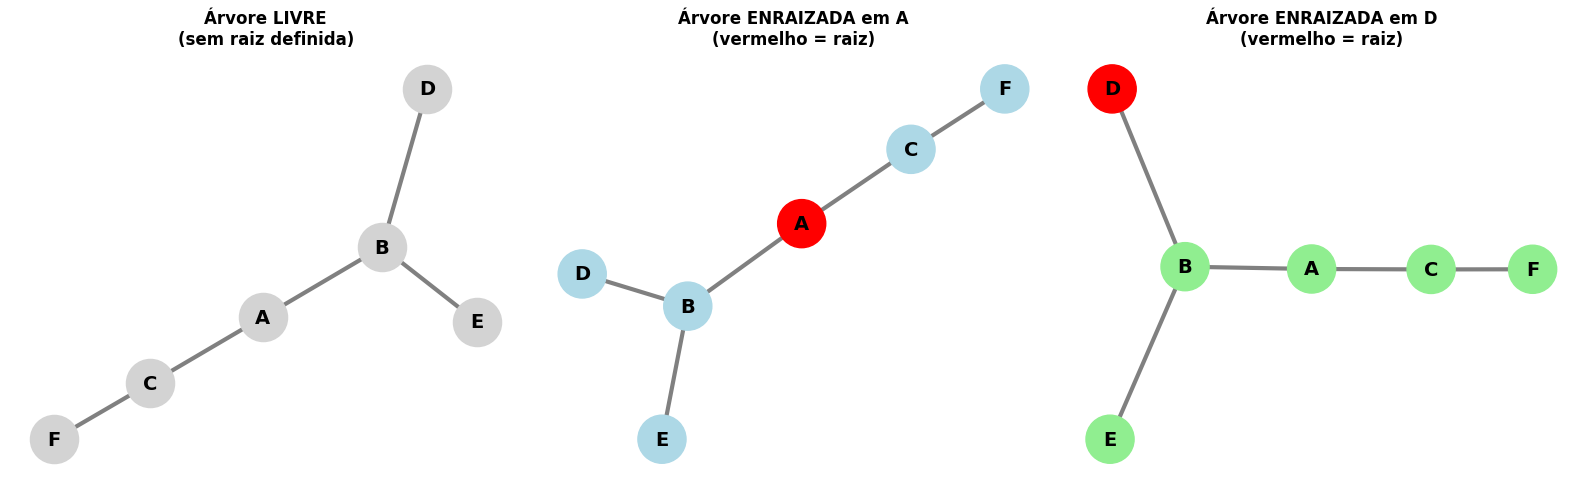


📌 Observação:
  A MESMA árvore pode ter diferentes interpretações hierárquicas
  dependendo da escolha do vértice raiz!


In [2]:
# Comparação visual: mesma árvore, diferentes raízes
T = nx.Graph()
T.add_edges_from([
    ('A', 'B'), ('A', 'C'),
    ('B', 'D'), ('B', 'E'),
    ('C', 'F')
])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Árvore livre (sem hierarquia)
pos1 = nx.spring_layout(T, seed=42)
nx.draw(T, pos1, ax=axes[0], with_labels=True, node_color='lightgray',
        node_size=1200, font_size=14, font_weight='bold', edge_color='gray', width=3)
axes[0].set_title('Árvore LIVRE\n(sem raiz definida)', fontweight='bold', fontsize=12)

# 2. Enraizada em A
pos2 = nx.nx_agraph.graphviz_layout(T, prog='dot', root='A') if 'pygraphviz' in dir() else nx.spring_layout(T, seed=1)
node_colors = ['red' if v == 'A' else 'lightblue' for v in T.nodes()]
nx.draw(T, pos2, ax=axes[1], with_labels=True, node_color=node_colors,
        node_size=1200, font_size=14, font_weight='bold', edge_color='gray', width=3)
axes[1].set_title('Árvore ENRAIZADA em A\n(vermelho = raiz)', fontweight='bold', fontsize=12)

# 3. Enraizada em D
pos3 = nx.nx_agraph.graphviz_layout(T, prog='dot', root='D') if 'pygraphviz' in dir() else nx.spring_layout(T, seed=2)
node_colors = ['red' if v == 'D' else 'lightgreen' for v in T.nodes()]
nx.draw(T, pos3, ax=axes[2], with_labels=True, node_color=node_colors,
        node_size=1200, font_size=14, font_weight='bold', edge_color='gray', width=3)
axes[2].set_title('Árvore ENRAIZADA em D\n(vermelho = raiz)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("\n📌 Observação:")
print("  A MESMA árvore pode ter diferentes interpretações hierárquicas")
print("  dependendo da escolha do vértice raiz!")

## 📏 Níveis em Árvores Enraizadas

> **Definição**: O **nível de um vértice** $x$ (em uma árvore enraizada) é igual à **distância entre o vértice raiz e o vértice** $x$.

$$\text{nível}(x) = d(\text{raiz}, x)$$

### Convenção Visual

- Árvore representada com a **raiz na parte superior**
- Vértice raiz está no **nível 0**
- Níveis aumentam de cima para baixo

C:\Users\leona\AppData\Local\Temp\ipykernel_6656\2076299296.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


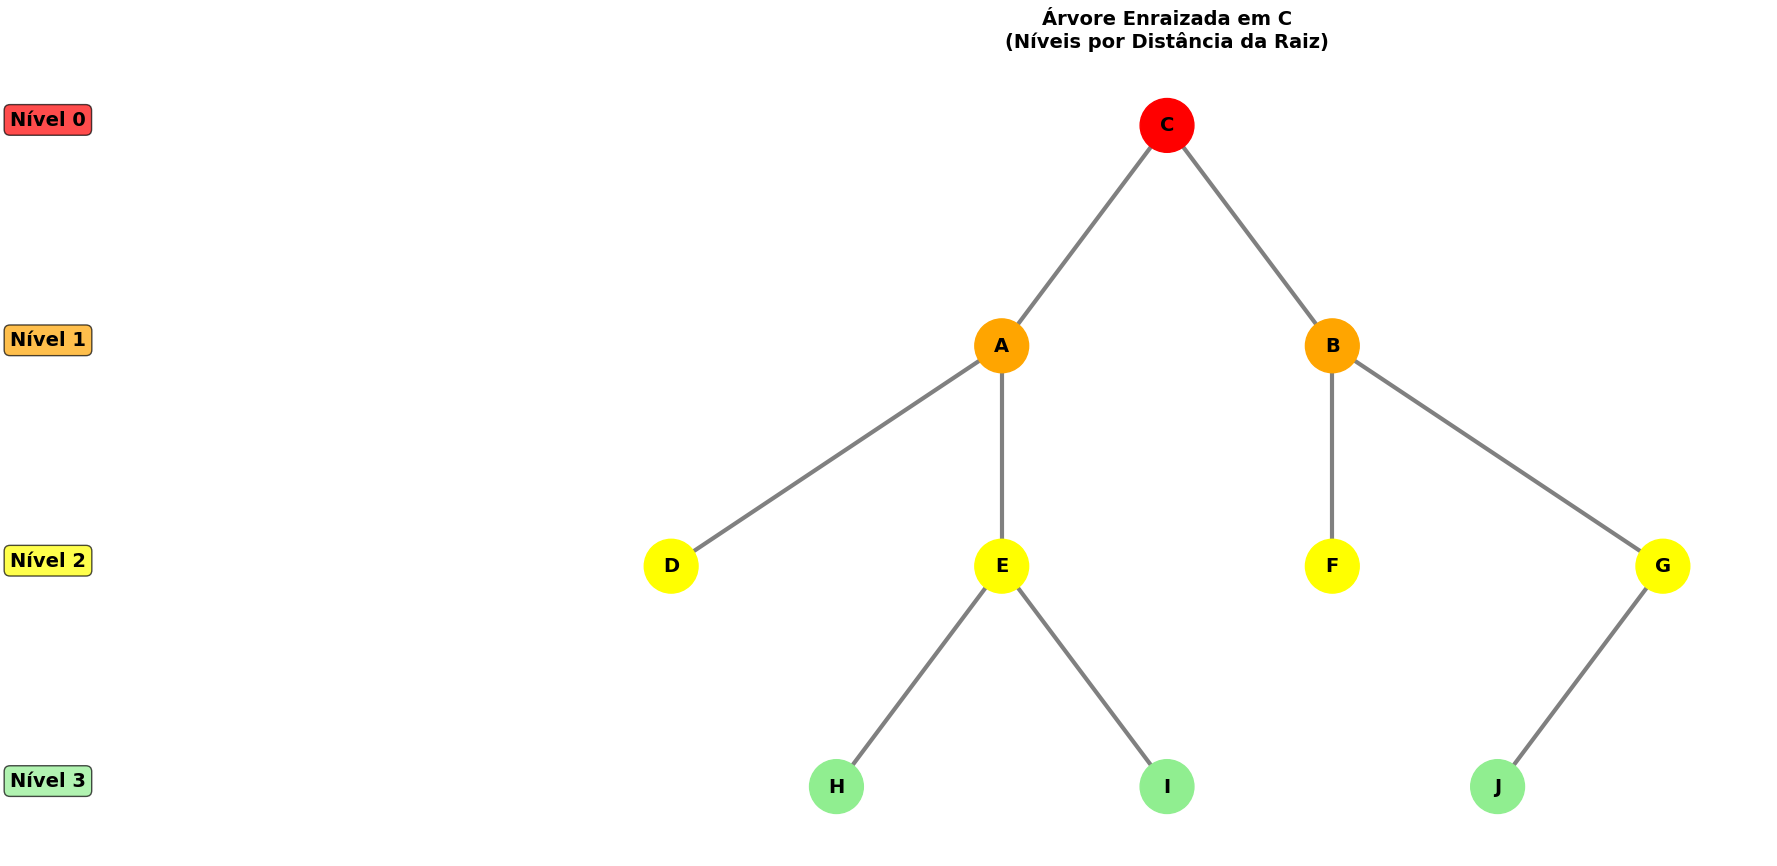


📊 Níveis dos Vértices:
  Nível 0: ['C']
  Nível 1: ['A', 'B']
  Nível 2: ['D', 'E', 'F', 'G']
  Nível 3: ['H', 'I', 'J']

✓ Raiz 'C' está no nível 0
✓ Altura da árvore: 3 (máximo nível)


In [3]:
# Criar árvore e calcular níveis
T = nx.Graph()
T.add_edges_from([
    ('C', 'A'), ('C', 'B'),          # Nível 1
    ('A', 'D'), ('A', 'E'),          # Nível 2
    ('B', 'F'), ('B', 'G'),          # Nível 2
    ('E', 'H'), ('E', 'I'),          # Nível 3
    ('G', 'J')                        # Nível 3
])

raiz = 'C'

# Calcular níveis (distância da raiz)
niveis = nx.single_source_shortest_path_length(T, raiz)

# Agrupar por nível
vertices_por_nivel = {}
for v, nivel in niveis.items():
    if nivel not in vertices_por_nivel:
        vertices_por_nivel[nivel] = []
    vertices_por_nivel[nivel].append(v)

# Visualizar com layout hierárquico
plt.figure(figsize=(12, 8))

# Cores por nível
cores_nivel = {0: 'red', 1: 'orange', 2: 'yellow', 3: 'lightgreen'}
node_colors = [cores_nivel[niveis[v]] for v in T.nodes()]

# Layout hierárquico manual
pos = {}
max_nivel = max(niveis.values())
for nivel, vertices in vertices_por_nivel.items():
    n_vertices = len(vertices)
    for i, v in enumerate(vertices):
        x = (i - n_vertices/2 + 0.5) * 2
        y = -(nivel * 2)  # Negativo para níveis crescerem para baixo
        pos[v] = (x, y)

nx.draw(T, pos, with_labels=True, node_color=node_colors,
        node_size=1500, font_size=14, font_weight='bold', edge_color='gray', width=3)

# Adicionar rótulos de nível
for nivel in range(max_nivel + 1):
    plt.text(-7, -nivel*2, f'Nível {nivel}', fontsize=14, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor=cores_nivel[nivel], alpha=0.7))

plt.title(f'Árvore Enraizada em {raiz}\n(Níveis por Distância da Raiz)', 
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print("\n📊 Níveis dos Vértices:")
print("="*50)
for nivel in sorted(vertices_por_nivel.keys()):
    print(f"  Nível {nivel}: {vertices_por_nivel[nivel]}")

print(f"\n✓ Raiz '{raiz}' está no nível 0")
print(f"✓ Altura da árvore: {max_nivel} (máximo nível)")

## 📐 Altura de uma Árvore Enraizada

> **Definição**: A **altura** de uma árvore enraizada é o **comprimento do maior caminho** existente na árvore a partir do vértice raiz.

$$\text{altura} = \max_{v \in V} d(\text{raiz}, v) = \max \{\text{nível}(v) : v \in V\}$$

### Interpretação

- Altura = profundidade máxima
- Número de "andares" - 1
- Caminho mais longo da raiz até uma folha

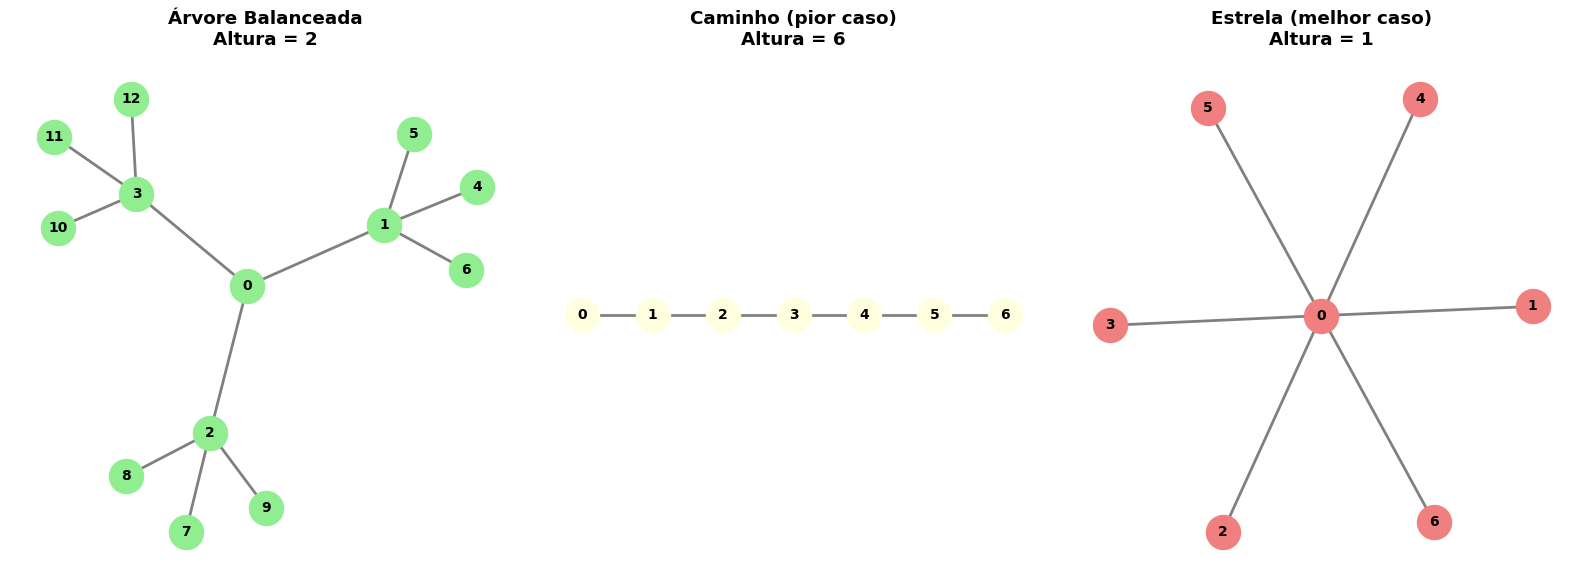


📏 Alturas Comparadas (todas com 7 vértices):
  Estrela:    altura = 1 (mínimo possível)
  Balanceada: altura = 2 (intermediário)
  Caminho:    altura = 6 (máximo possível)

✓ Para n vértices: 1 ≤ altura ≤ n-1


In [4]:
# Comparar alturas de diferentes árvores
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# 1. Árvore balanceada (altura pequena)
T1 = nx.balanced_tree(3, 2)  # branching=3, altura=2
altura1 = nx.eccentricity(T1, v=0)
pos1 = nx.spring_layout(T1, seed=42)
nx.draw(T1, pos1, ax=axes[0], with_labels=True, node_color='lightgreen',
        node_size=600, font_size=10, font_weight='bold', edge_color='gray', width=2)
axes[0].set_title(f'Árvore Balanceada\nAltura = {altura1}', fontweight='bold')

# 2. Caminho (altura máxima)
T2 = nx.path_graph(7)
altura2 = nx.eccentricity(T2, v=0)
pos2 = {i: (i, 0) for i in T2.nodes()}
nx.draw(T2, pos2, ax=axes[1], with_labels=True, node_color='lightyellow',
        node_size=600, font_size=10, font_weight='bold', edge_color='gray', width=2)
axes[1].set_title(f'Caminho (pior caso)\nAltura = {altura2}', fontweight='bold')

# 3. Árvore em estrela (altura mínima)
T3 = nx.star_graph(6)
altura3 = nx.eccentricity(T3, v=0)
pos3 = nx.spring_layout(T3, seed=42)
nx.draw(T3, pos3, ax=axes[2], with_labels=True, node_color='lightcoral',
        node_size=600, font_size=10, font_weight='bold', edge_color='gray', width=2)
axes[2].set_title(f'Estrela (melhor caso)\nAltura = {altura3}', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📏 Alturas Comparadas (todas com 7 vértices):")
print("="*50)
print(f"  Estrela:    altura = {altura3} (mínimo possível)")
print(f"  Balanceada: altura = {altura1} (intermediário)")
print(f"  Caminho:    altura = {altura2} (máximo possível)")
print("\n✓ Para n vértices: 1 ≤ altura ≤ n-1")

## 🔘 Vértice Interno

> **Definição**: Um vértice **não pendente** em uma árvore é chamado de **vértice interno**.

- **Vértice interno**: grau ≥ 2 (tem "filhos")
- **Vértice pendente** (folha): grau = 1 (sem "filhos")

### Observação

Em árvores enraizadas:
- Raiz pode ser interna (grau ≥ 2) ou pendente (se for o único vértice)
- Folhas estão sempre no "fundo" da árvore

C:\Users\leona\AppData\Local\Temp\ipykernel_6656\2263234981.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


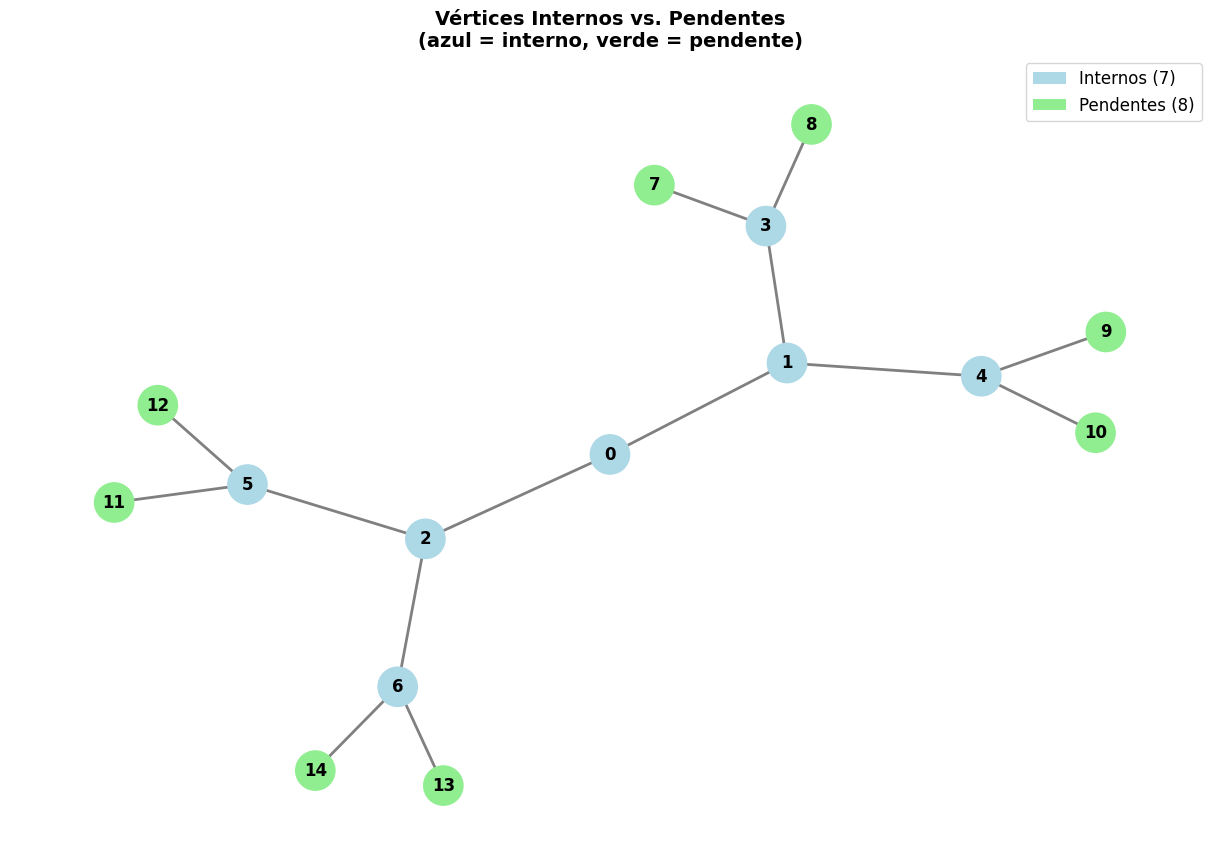


📊 Estatísticas:
  Total de vértices (n): 15
  Vértices internos: 7
  Vértices pendentes (folhas): 8
  Verificação: 7 + 8 = 15 ✓


In [5]:
# Identificar vértices internos vs. pendentes
T = nx.balanced_tree(2, 3)  # árvore binária, altura 3

# Classificar vértices
internos = [v for v in T.nodes() if T.degree(v) >= 2]
pendentes = [v for v in T.nodes() if T.degree(v) == 1]

# Colorir
cores = ['lightblue' if v in internos else 'lightgreen' for v in T.nodes()]

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(T, seed=42)
nx.draw(T, pos, with_labels=True, node_color=cores,
        node_size=800, font_size=12, font_weight='bold', edge_color='gray', width=2)

# Legenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightblue', label=f'Internos ({len(internos)})'),
    Patch(facecolor='lightgreen', label=f'Pendentes ({len(pendentes)})')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.title('Vértices Internos vs. Pendentes\n(azul = interno, verde = pendente)',
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

n = T.number_of_nodes()
print(f"\n📊 Estatísticas:")
print("="*50)
print(f"  Total de vértices (n): {n}")
print(f"  Vértices internos: {len(internos)}")
print(f"  Vértices pendentes (folhas): {len(pendentes)}")
print(f"  Verificação: {len(internos)} + {len(pendentes)} = {n} ✓")

## 🌳 Árvore Binária Completa

> **Definição**: Uma **árvore binária completa** (Complete Binary Tree) é uma árvore enraizada que satisfaz:
>
> 1. Existe **exatamente um vértice de grau 2** (naturalmente o vértice raiz)
> 2. Cada um dos vértices restantes tem **grau 1 ou 3**

### Interpretação

- **Raiz**: grau 2 (dois filhos)
- **Vértices internos**: grau 3 (um pai + dois filhos)
- **Folhas**: grau 1 (apenas um pai)

### Estrutura

- Todos os vértices internos têm **exatamente 2 filhos**
- É uma árvore **binária estrita** ou **própria**

C:\Users\leona\AppData\Local\Temp\ipykernel_6656\4179274806.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


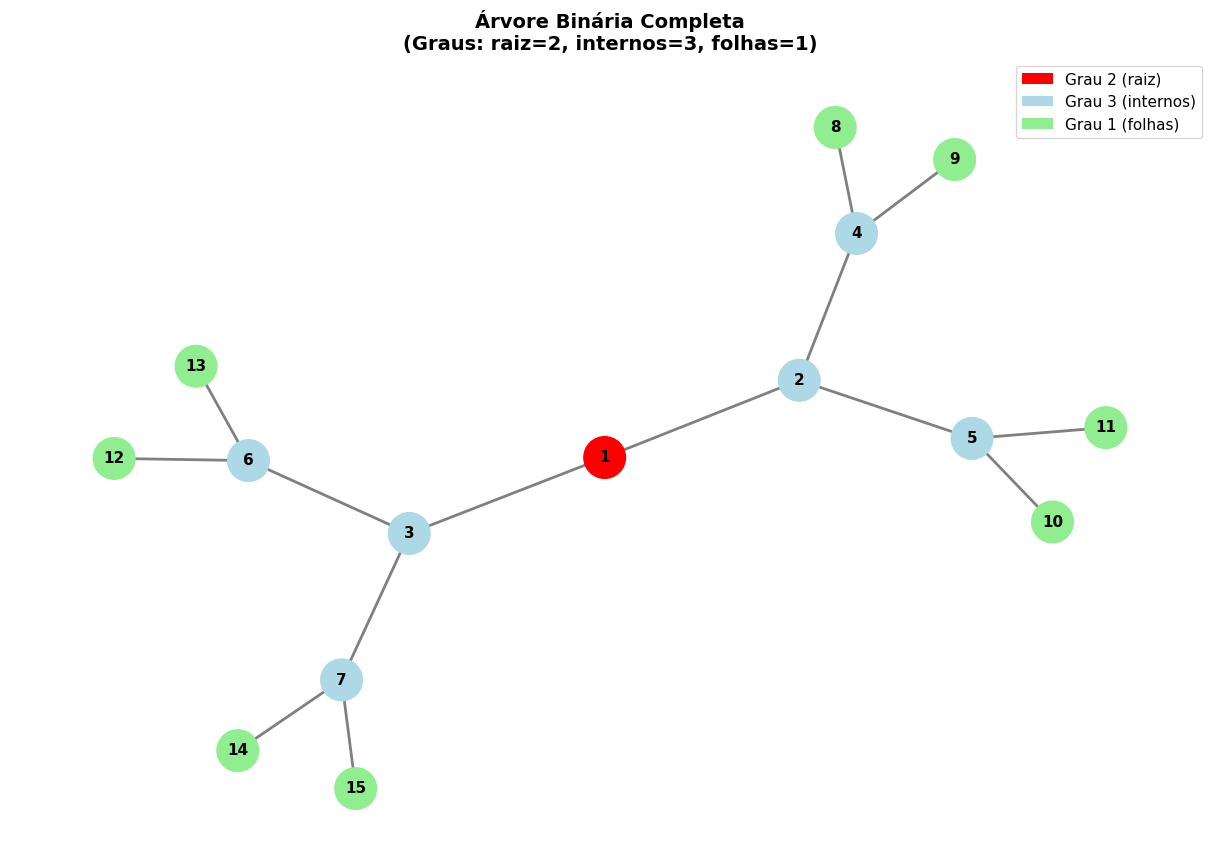


📊 Propriedades da Árvore Binária Completa:
  Total de vértices (n): 15
  Vértices de grau 2 (raiz): 1 ✓ (deve ser 1)
  Vértices de grau 3 (internos): 6
  Vértices de grau 1 (folhas): 8

  Distribuição de graus: [1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 3, 3, 3, 3, 3]
  ✓ Apenas graus 1, 2, 3 aparecem
  ✓ Exatamente UM vértice de grau 2


In [6]:
# Criar árvore binária completa
def arvore_binaria_completa(altura):
    """Cria uma árvore binária completa de altura h"""
    T = nx.Graph()
    
    def adicionar_nivel(pai, nivel, max_nivel):
        if nivel > max_nivel:
            return
        
        # Adicionar filhos
        esquerda = 2 * pai
        direita = 2 * pai + 1
        
        T.add_edge(pai, esquerda)
        T.add_edge(pai, direita)
        
        adicionar_nivel(esquerda, nivel + 1, max_nivel)
        adicionar_nivel(direita, nivel + 1, max_nivel)
    
    T.add_node(1)  # raiz
    adicionar_nivel(1, 1, altura)
    
    return T

# Criar e visualizar
T_binaria = arvore_binaria_completa(3)

# Analisar graus
graus = dict(T_binaria.degree())
grau_2 = [v for v, g in graus.items() if g == 2]
grau_1 = [v for v, g in graus.items() if g == 1]
grau_3 = [v for v, g in graus.items() if g == 3]

# Colorir por grau
cores = []
for v in T_binaria.nodes():
    if graus[v] == 2:
        cores.append('red')       # raiz
    elif graus[v] == 3:
        cores.append('lightblue') # internos
    else:
        cores.append('lightgreen') # folhas

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(T_binaria, seed=42)
nx.draw(T_binaria, pos, with_labels=True, node_color=cores,
        node_size=900, font_size=11, font_weight='bold', edge_color='gray', width=2)

# Legenda
legend_elements = [
    Patch(facecolor='red', label='Grau 2 (raiz)'),
    Patch(facecolor='lightblue', label='Grau 3 (internos)'),
    Patch(facecolor='lightgreen', label='Grau 1 (folhas)')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=11)

plt.title('Árvore Binária Completa\n(Graus: raiz=2, internos=3, folhas=1)',
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

n = T_binaria.number_of_nodes()
print(f"\n📊 Propriedades da Árvore Binária Completa:")
print("="*60)
print(f"  Total de vértices (n): {n}")
print(f"  Vértices de grau 2 (raiz): {len(grau_2)} ✓ (deve ser 1)")
print(f"  Vértices de grau 3 (internos): {len(grau_3)}")
print(f"  Vértices de grau 1 (folhas): {len(grau_1)}")
print(f"\n  Distribuição de graus: {sorted(graus.values())}")
print(f"  ✓ Apenas graus 1, 2, 3 aparecem")
print(f"  ✓ Exatamente UM vértice de grau 2")

## 📊 Proposição 1: n sempre Ímpar

> **Proposição 1**: O número de vértices $n$ em uma árvore binária completa (com 3 ou mais vértices) é sempre **ímpar**.

### Demonstração

1. Existe **exatamente 1 vértice** de grau par (a raiz, grau 2)
2. Os $n-1$ vértices restantes têm grau **ímpar** (1 ou 3)
3. Em qualquer grafo, o número de vértices de grau ímpar é **par** (lema do aperto de mão)
4. Logo: $n - 1$ é par
5. Portanto: $n$ é **ímpar** ✓

In [7]:
# Verificar Proposição 1: n é ímpar
print("\n🔍 Verificando Proposição 1: n sempre ÍMPAR")
print("="*60)

for h in range(1, 6):
    T = arvore_binaria_completa(h)
    n = T.number_of_nodes()
    
    # Contar graus
    graus = dict(T.degree())
    grau_par = sum(1 for g in graus.values() if g % 2 == 0)
    grau_impar = sum(1 for g in graus.values() if g % 2 == 1)
    
    print(f"  Altura {h}: n = {n} {'(ímpar ✓)' if n % 2 == 1 else '(PAR ✗)'}")
    print(f"    Vértices grau par: {grau_par}")
    print(f"    Vértices grau ímpar: {grau_impar} (deve ser par: {grau_impar % 2 == 0})")

print("\n✓ TODAS as árvores binárias completas têm n ímpar!")
print("✓ Sequência: 1, 3, 7, 15, 31, ... (2^(h+1) - 1)")


🔍 Verificando Proposição 1: n sempre ÍMPAR
  Altura 1: n = 3 (ímpar ✓)
    Vértices grau par: 1
    Vértices grau ímpar: 2 (deve ser par: True)
  Altura 2: n = 7 (ímpar ✓)
    Vértices grau par: 1
    Vértices grau ímpar: 6 (deve ser par: True)
  Altura 3: n = 15 (ímpar ✓)
    Vértices grau par: 1
    Vértices grau ímpar: 14 (deve ser par: True)
  Altura 4: n = 31 (ímpar ✓)
    Vértices grau par: 1
    Vértices grau ímpar: 30 (deve ser par: True)
  Altura 5: n = 63 (ímpar ✓)
    Vértices grau par: 1
    Vértices grau ímpar: 62 (deve ser par: True)

✓ TODAS as árvores binárias completas têm n ímpar!
✓ Sequência: 1, 3, 7, 15, 31, ... (2^(h+1) - 1)


## 🍃 Proposição 2: Número de Vértices Pendentes

> **Proposição 2**: Seja $p$ o número de vértices pendentes em uma árvore binária completa com $n$ vértices. Então:
>
> $$p = \frac{n+1}{2}$$

### Demonstração

Seja $i$ o número de vértices internos (grau 2 ou 3).

1. $n = p + i$ (total = pendentes + internos)
2. Soma dos graus: $\sum \text{grau}(v) = 2(n-1)$ (árvore tem $n-1$ arestas)
3. Soma dos graus = $p \cdot 1 + 1 \cdot 2 + (i-1) \cdot 3$
   - $p$ folhas de grau 1
   - 1 raiz de grau 2  
   - $i-1$ internos de grau 3
4. Logo: $p + 2 + 3(i-1) = 2(n-1)$
5. Simplificando: $p + 3i - 1 = 2n - 2$
6. $p = 2n - 2 - 3i + 1 = 2n - 3i - 1$
7. Como $n = p + i$: $p = 2(p+i) - 3i - 1 = 2p + 2i - 3i - 1 = 2p - i - 1$
8. $p = i + 1$
9. Substituindo em $n = p + i$: $n = (i+1) + i = 2i + 1$
10. Logo: $i = \frac{n-1}{2}$ e $p = \frac{n-1}{2} + 1 = \frac{n+1}{2}$ ✓


🔍 Verificando Proposição 2: p = (n+1)/2
Altura     n          Pendentes (p)      (n+1)/2         Válido?
1          3          2                  2               ✓
2          7          4                  4               ✓
3          15         8                  8               ✓
4          31         16                 16              ✓
5          63         32                 32              ✓
6          127        64                 64              ✓

✓ Fórmula p = (n+1)/2 SEMPRE válida para árvores binárias completas!


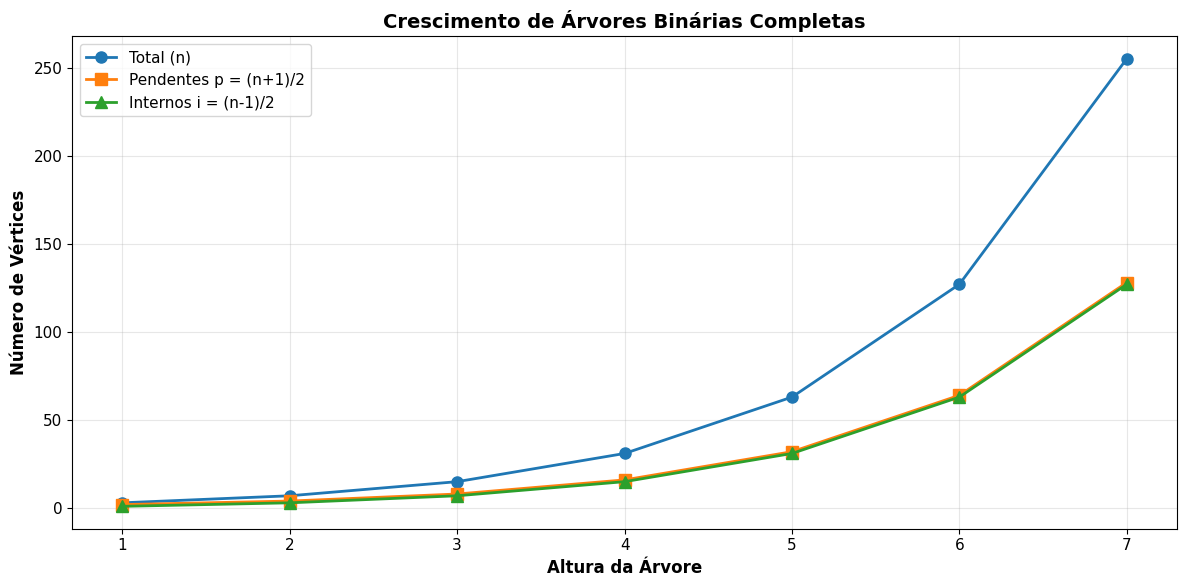

In [8]:
# Verificar Proposição 2: p = (n+1)/2
print("\n🔍 Verificando Proposição 2: p = (n+1)/2")
print("="*70)
print(f"{'Altura':<10} {'n':<10} {'Pendentes (p)':<18} {'(n+1)/2':<15} {'Válido?'}")
print("="*70)

for h in range(1, 7):
    T = arvore_binaria_completa(h)
    n = T.number_of_nodes()
    
    # Contar pendentes
    pendentes = sum(1 for v in T.nodes() if T.degree(v) == 1)
    
    # Fórmula
    p_formula = (n + 1) // 2
    
    valido = (pendentes == p_formula)
    
    print(f"{h:<10} {n:<10} {pendentes:<18} {p_formula:<15} {'✓' if valido else '✗'}")

print("\n✓ Fórmula p = (n+1)/2 SEMPRE válida para árvores binárias completas!")

# Visualização
alturas = list(range(1, 8))
n_vertices = [2**(h+1) - 1 for h in alturas]
pendentes = [(n+1)//2 for n in n_vertices]
internos = [n - p for n, p in zip(n_vertices, pendentes)]

plt.figure(figsize=(12, 6))
x = np.array(alturas)
plt.plot(x, n_vertices, 'o-', label='Total (n)', linewidth=2, markersize=8)
plt.plot(x, pendentes, 's-', label='Pendentes p = (n+1)/2', linewidth=2, markersize=8)
plt.plot(x, internos, '^-', label='Internos i = (n-1)/2', linewidth=2, markersize=8)

plt.xlabel('Altura da Árvore', fontsize=12, fontweight='bold')
plt.ylabel('Número de Vértices', fontsize=12, fontweight='bold')
plt.title('Crescimento de Árvores Binárias Completas', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 📈 Relações em Árvores Binárias Completas

### Fórmulas Fundamentais

Para uma árvore binária completa de altura $h$:

| Propriedade | Fórmula |
|-------------|--------|
| **Total de vértices** | $n = 2^{h+1} - 1$ |
| **Vértices pendentes** | $p = \frac{n+1}{2} = 2^h$ |
| **Vértices internos** | $i = \frac{n-1}{2} = 2^h - 1$ |
| **Arestas** | $m = n - 1 = 2^{h+1} - 2$ |

### Propriedades

- $n$ é sempre **ímpar**
- $p = i + 1$ (uma folha a mais que internos)
- $n = 2i + 1$ (relação linear)

In [9]:
# Tabela completa de propriedades
print("\n📊 Propriedades de Árvores Binárias Completas")
print("="*80)
print(f"{'h':<5} {'n':<8} {'p (folhas)':<12} {'i (internos)':<15} {'m (arestas)':<12} {'p=i+1?'}")
print("="*80)

for h in range(0, 8):
    n = 2**(h+1) - 1
    p = (n + 1) // 2
    i = (n - 1) // 2
    m = n - 1
    
    print(f"{h:<5} {n:<8} {p:<12} {i:<15} {m:<12} {p == i+1}")

print("\n✓ Todas as relações verificadas!")


📊 Propriedades de Árvores Binárias Completas
h     n        p (folhas)   i (internos)    m (arestas)  p=i+1?
0     1        1            0               0            True
1     3        2            1               2            True
2     7        4            3               6            True
3     15       8            7               14           True
4     31       16           15              30           True
5     63       32           31              62           True
6     127      64           63              126          True
7     255      128          127             254          True

✓ Todas as relações verificadas!


## 🎯 Resumo

### Definições

| Conceito | Definição |
|----------|----------|
| **Árvore Livre** | Árvore sem raiz distinguida |
| **Árvore Enraizada** | Árvore com vértice raiz especial |
| **Nível de v** | Distância $d(\text{raiz}, v)$ |
| **Altura** | Máximo nível na árvore |
| **Vértice Interno** | Vértice não-pendente (grau ≥ 2) |
| **Árvore Binária Completa** | Raiz grau 2, demais grau 1 ou 3 |

### Proposições Importantes

1. **Proposição 1**: Em árvore binária completa, $n$ é sempre **ímpar**
2. **Proposição 2**: Número de folhas: $p = \frac{n+1}{2}$

### Fórmulas para Árvores Binárias Completas

- $n = 2^{h+1} - 1$ (total de vértices)
- $p = 2^h$ (folhas)
- $i = 2^h - 1$ (internos)
- $p = i + 1$ (sempre uma folha a mais)

### Próximo Notebook

No último notebook, estudaremos o **centro de um grafo** e métodos para encontrá-lo em árvores!

## 📝 Exercícios

1. Prove que em uma árvore enraizada de altura $h$, existem no máximo $2^h$ folhas.
2. Crie uma árvore binária completa com exatamente 15 vértices.
3. Mostre que em uma árvore binária completa, $\sum \text{grau}(v) = 2n - 2$.
4. Implemente uma função que calcule a altura de uma árvore enraizada.
5. Verifique que $p - i = 1$ para qualquer árvore binária completa.